In [1]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [56]:
import os
import json
import pandas as pd
import re
from pathlib import Path

def collect_results_json_recursive(root_dir='re-pro-motivation'):
    # Dictionary to store all the extracted data
    all_data = []
    
    # Regex pattern to extract region and function from R1-49-output format
    region_function_pattern = r'R(\d+)-(\d+)-output'
    
    # Walk through all directories and subdirectories
    for dirpath, dirnames, filenames in os.walk(root_dir):
        if 'results.json' in filenames:
            json_path = os.path.join(dirpath, 'results.json')
            
            # Parse the path components
            path_parts = Path(dirpath).parts
            
            # Initialize variables to store extracted information
            region = None
            function = None
            infrastructure = None
            approach = None
            experiment = None
            repetition = None
            week = None
            proactive_approach = 'reactive'
            
            # Extract information from path components
            for i, part in enumerate(path_parts):
                # Extract region and function
                region_function_match = re.match(region_function_pattern, part)
                if region_function_match:
                    region = f"R{region_function_match.group(1)}"
                    function = region_function_match.group(2)
                
                # Extract infrastructure
                if part.startswith('infra-'):
                    infrastructure = part
                
                # Extract approach
                if part.startswith('results-'):
                    approach = part.replace('results-', '')

                # Extract proactive approach
                if part == 'first_second':
                    proactive_approach = 'first_second'
                elif part == 'all':
                    proactive_approach = 'all'
                
                # Extract experiment (timestamp)
                if re.match(r'\d{8}-\d{6}-\d{6}', part):
                    experiment = part
                
                # Extract repetition and week
                if experiment and i < len(path_parts) - 1:
                    if path_parts[i] == experiment and i + 1 < len(path_parts):
                        repetition = path_parts[i+1]
                    if path_parts[i] == experiment and i + 2 < len(path_parts):
                        week = path_parts[i+2]
            
            try:
                # Read the JSON file
                with open(json_path, 'r') as f:
                    results_data = json.load(f)
                
                # Create a dictionary with path information and results data
                entry = {
                    'region': region,
                    'function': function,
                    'infrastructure': infrastructure,
                    'approach': approach,
                    'proactive_approach': proactive_approach,
                    'experiment': experiment,
                    'repetition': repetition,
                    'week': week
                }
                
                # Add all the keys and values from results.json
                for key, value in results_data.items():
                    entry[key] = value
                
                all_data.append(entry)
                
            except json.JSONDecodeError:
                print(f"Error decoding JSON in {json_path}")
            except Exception as e:
                print(f"Error reading {json_path}: {e}")
    
    # Create a DataFrame from all collected data
    if all_data:
        df = pd.DataFrame(all_data)
    else:
        df = pd.DataFrame()
    
    return df

# Example usage
if __name__ == "__main__":
    results_df = collect_results_json_recursive()
    print(results_df)
    
    # Optionally save to CSV
    # results_df.to_csv('combined_results.csv')


   region function infrastructure   approach proactive_approach  \
0      R1     1233        infra-1  proactive                all   
1      R1     1233        infra-1  proactive                all   
2      R1     1233        infra-1  proactive                all   
3      R1     1233        infra-1  proactive                all   
4      R1     1233        infra-1  proactive       first_second   
5      R1     1233        infra-1  proactive       first_second   
6      R1     1233        infra-1  proactive       first_second   
7      R1     1233        infra-1  proactive       first_second   
8      R1     1233        infra-1   reactive           reactive   
9      R1     1233        infra-1   reactive           reactive   
10     R1     1233        infra-1   reactive           reactive   
11     R1     1233        infra-1   reactive           reactive   
12     R1     1233        infra-1   reactive           reactive   
13     R1     1233        infra-1   reactive           reactiv

In [57]:
results_df

,region,function,infrastructure,approach,proactive_approach,experiment,repetition,week,averageQueueTime,penaltyProportion,averageExecutionTime,averageComputerTime,averageWaitTime,endTime
0,R1,1233,infra-1,proactive,all,20250310-161118-666001,0,3,1.397691,7.618832,0.003733,0.024811,0.0,1200.015614
1,R1,1233,infra-1,proactive,all,20250310-161118-666001,0,2,2.155131,10.317848,0.001790,0.022868,0.0,1199.940266
2,R1,1233,infra-1,proactive,all,20250310-161118-666001,0,0,1.424998,7.627296,0.001048,0.022125,0.0,1199.992922
3,R1,1233,infra-1,proactive,all,20250310-161118-666001,0,1,1.517311,7.964210,0.001856,0.022934,0.0,1199.932598
4,R1,1233,infra-1,proactive,first_second,20250310-155757-524259,0,3,1.468537,7.845473,0.001331,0.022409,0.0,1199.992142
5,R1,1233,infra-1,proactive,first_second,20250310-155757-524259,0,2,2.121829,9.643300,0.002103,0.023180,0.0,1199.940266
6,R1,1233,infra-1,proactive,first_second,20250310-155757-524259,0,0,1.494440,7.885103,0.003664,0.024742,0.0,1200.008423
7,R1,1233,infra-1,proactive,first_second,20250310-155757-524259,0,1,1.596837,8.375564,0.003206,0.024284,0.0,1199.932598
8,R1,1233,infra-1,reactive,reactive,20250310-154218-883815,0,3,1.686262,13.814825,0.001148,0.021449,0.0,1208.044632
9,R1,1233,infra-1,reactive,reactive,20250310-154218-883815,0,2,2.148003,12.852597,0.001648,0.021303,0.0,1200.219538


In [58]:
third_four_df = results_df[results_df['week'] != '0']
third_four_df = third_four_df[third_four_df['week'] != '1']

In [18]:
third_four_df

,region,function,infrastructure,approach,experiment,repetition,week,averageQueueTime,penaltyProportion,averageExecutionTime,averageComputerTime,averageWaitTime,endTime
0,R1,1437,infra-1,reactive,20250310-101036-865039,0,3,1.704833,12.848158,0.001854,0.021480,0.0,1207.070852
1,R1,1437,infra-1,reactive,20250310-101036-865039,0,2,2.388221,13.686904,0.001851,0.022259,0.0,1201.733305
4,R1,1437,infra-1,proactive,20250310-102903-479981,0,3,1.508724,7.696042,0.003567,0.024537,0.0,1199.969553
5,R1,1437,infra-1,proactive,20250310-102903-479981,0,2,2.381685,11.278160,0.003918,0.024996,0.0,1199.952709
8,R1,1465,infra-1,reactive,20250310-101313-514988,0,3,0.592217,35.437958,0.003581,0.022455,0.0,1202.283400
9,R1,1465,infra-1,reactive,20250310-101313-514988,0,2,0.322333,2.409521,0.001735,0.020147,0.0,1199.948212
12,R1,1465,infra-1,proactive,20250310-103124-671971,0,3,0.596288,3.081918,0.001222,0.022300,0.0,1199.937701
13,R1,1465,infra-1,proactive,20250310-103124-671971,0,2,1.503005,6.664197,0.001187,0.022264,0.0,1199.946451
16,R1,2119,infra-1,reactive,20250310-101421-426737,0,3,1.548042,11.763078,0.001486,0.022053,0.0,1199.955478
17,R1,2119,infra-1,reactive,20250310-101421-426737,0,2,1.342371,9.218566,0.001736,0.021641,0.0,1199.973429


<Axes: xlabel='function', ylabel='penaltyProportion'>

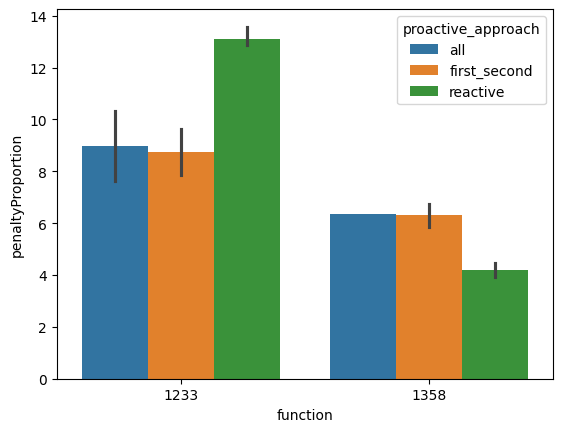

In [59]:
sns.barplot(x='function', y='penaltyProportion', hue='proactive_approach', data=third_four_df)

<Axes: xlabel='function', ylabel='penaltyProportion'>

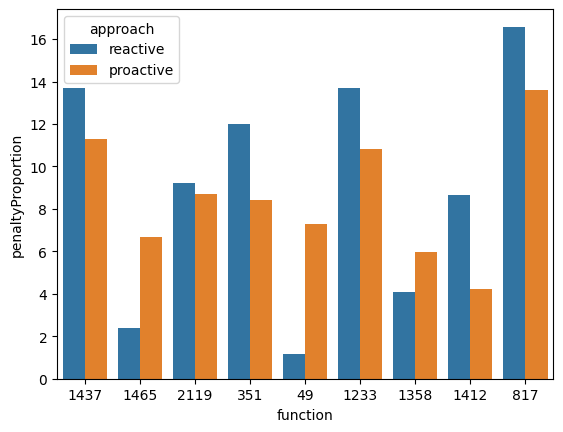

In [19]:
sns.barplot(x='function', y='penaltyProportion', hue='approach', data=third_four_df[third_four_df['week'] == '2'])

<Axes: xlabel='function', ylabel='penaltyProportion'>

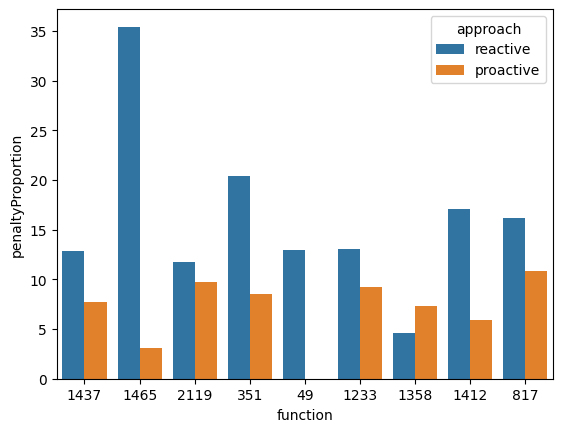

In [20]:
sns.barplot(x='function', y='penaltyProportion', hue='approach', data=third_four_df[third_four_df['week'] == '3'])

<Axes: xlabel='function', ylabel='penaltyProportion'>

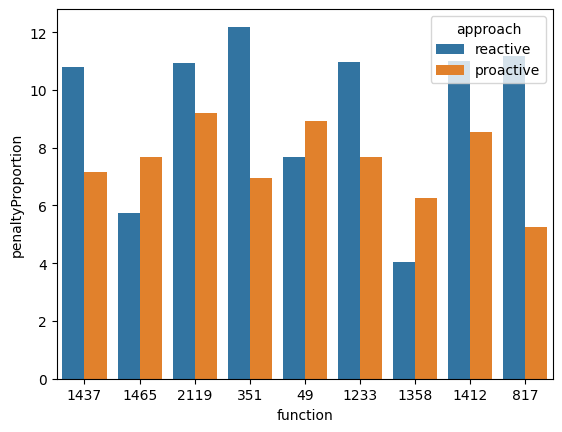

In [23]:
sns.barplot(x='function', y='penaltyProportion', hue='approach', data=results_df[results_df['week'] == '1'])

<Axes: xlabel='function', ylabel='penaltyProportion'>

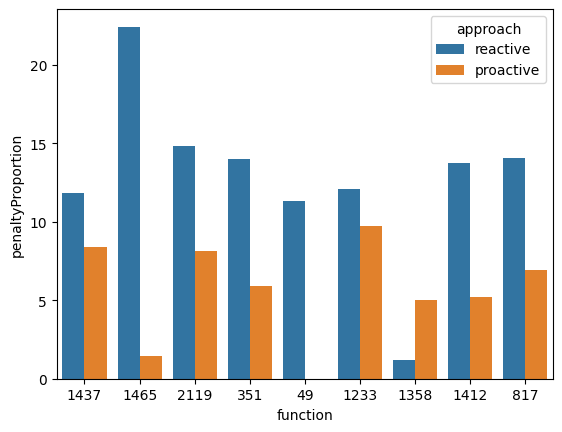

In [24]:
sns.barplot(x='function', y='penaltyProportion', hue='approach', data=results_df[results_df['week'] == '0'])

<Axes: xlabel='week', ylabel='penaltyProportion'>

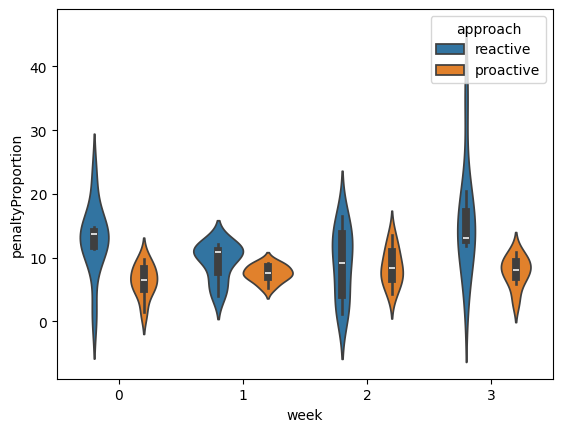

In [41]:
sns.violinplot(x='week', y='penaltyProportion', hue='approach', data=results_df.sort_values(by='week'))

In [34]:
# For a more detailed analysis including other factors
detailed_df = results_df.groupby(['week', 'region', 'function', 'infrastructure', 'approach'])['penaltyProportion'].mean().reset_index()

# Create a function to calculate percentage change for each group
def calculate_percentage_change(group):
    if len(group) != 2 or not {'reactive', 'proactive'}.issubset(group['approach'].values):
        return group  # Return unchanged if we don't have both approaches
    
    reactive_val = group.loc[group['approach'] == 'reactive', 'penaltyProportion'].values[0]
    proactive_val = group.loc[group['approach'] == 'proactive', 'penaltyProportion'].values[0]
    
    # Add percentage change to both rows
    group['percentage_change'] = ((proactive_val - reactive_val) / reactive_val * 100)
    return group

# Apply the function to each group
result_df = detailed_df.groupby(['week', 'region', 'function', 'infrastructure']).apply(calculate_percentage_change).reset_index(drop=True)

# Display the results
print(result_df)


   week region function infrastructure   approach  penaltyProportion  \
0     0     R1     1233        infra-1  proactive           9.739148   
1     0     R1     1233        infra-1   reactive          12.059411   
2     0     R1     1358        infra-1  proactive           5.010728   
3     0     R1     1358        infra-1   reactive           1.199466   
4     0     R1     1412        infra-1  proactive           5.183873   
..  ...    ...      ...            ...        ...                ...   
65    3     R1      351        infra-1  proactive           8.536527   
66    3     R1      351        infra-1   reactive          20.409961   
67    3     R1       49        infra-1   reactive          12.940640   
68    3     R1      817        infra-1  proactive          10.811550   
69    3     R1      817        infra-1   reactive          16.225684   

    percentage_change  
0          -19.240265  
1          -19.240265  
2          317.746479  
3          317.746479  
4          -62.

/tmp/ipykernel_26017/2310582950.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result_df = detailed_df.groupby(['week', 'region', 'function', 'infrastructure']).apply(calculate_percentage_change).reset_index(drop=True)


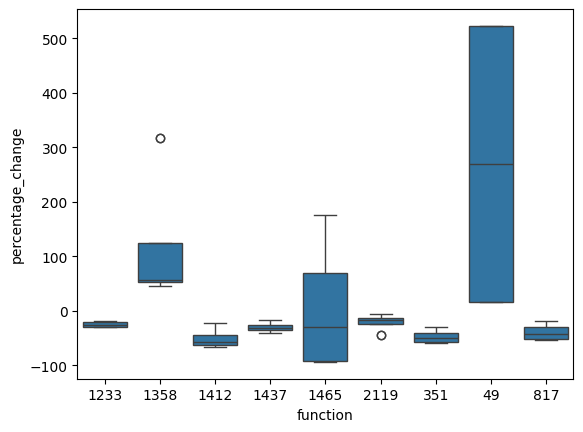

In [51]:
third_four_week = result_df[result_df['week'] != '0']
third_four_week = third_four_week[third_four_week['week'] != '1']
g = sns.boxplot(x='function', y='percentage_change', data=result_df)
# g.set_yscale("symlog")